# Decision Trees Classification Assignment
## Medina County Career Center — AI/ML

**Your task:** Build a decision tree classification model from scratch using one of the datasets below.

You've seen the full process in the Iris class example. Now it's your turn!

---

### Choose Your Dataset

Pick ONE of these datasets. Each has a different classification target:

| Dataset | How to Load | What You Predict | Rows | Features | Classes | Difficulty |
|---------|-------------|------------------|------|----------|---------|------------|
| **Palmer Penguins** | `sns.load_dataset('penguins')` | Penguin species | 344 | 4 numeric | 3 | Easy |
| **Wine Recognition** | `load_wine(as_frame=True)` | Wine cultivar (vineyard) | 178 | 13 numeric | 3 | Easy-Medium |
| **Breast Cancer Wisconsin** | `load_breast_cancer(as_frame=True)` | Malignant vs Benign | 569 | 30 numeric | 2 | Medium |

See the **Dataset Guide** for full descriptions of each one.

**Note:** Wine and Breast Cancer are built into scikit-learn — no internet needed. Palmer Penguins is in seaborn.

---

### The Steps (follow this structure)

1. Import libraries (no installs needed!)
2. Load your chosen dataset
3. Explore: check shape, columns, missing values, and clean the data
4. Drop any non-numeric columns (if your dataset has them)
5. Make at least ONE scatter plot — pick two features and color by class
6. Train/test split (80/20)
7. Build and train a DecisionTreeClassifier (set max_depth=3 to start)
8. Evaluate: print accuracy and the classification report
9. Show the confusion matrix as a heatmap
10. Visualize the tree using plot_tree
11. Show feature importance as a bar chart
12. Try changing max_depth and compare accuracy

## Step 1: Install + Import Libraries

In [ ]:
# No extra installs needed!
# Palmer Penguins is in seaborn, Wine and Breast Cancer are in sklearn
print("All datasets are built-in — no pip install needed!")

In [1]:
# Import your libraries here
# Hint: you need pandas, numpy, matplotlib, seaborn, sklearn stuff
# If using UCI, also import from ucimlrepo
# Look at the class example if you need a reminder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2: Load Your Dataset

**Palmer Penguins:** `sns.load_dataset('penguins')`

**Wine Recognition:** `from sklearn.datasets import load_wine` then `wine = load_wine(as_frame=True)`

**Breast Cancer:** `from sklearn.datasets import load_breast_cancer` then `cancer = load_breast_cancer(as_frame=True)`

In [2]:
# Load your chosen dataset
# --- LOAD (pick the one that matches your dataset) ---

# Palmer Penguins (from seaborn):
df = sns.load_dataset('penguins')

## Step 3: Explore the Data

Print the shape, column names, first few rows, and check for missing values. If there are missing values, drop them.

In [3]:
# Explore your data here
# - How many rows and columns?
# - What are the column names?
# - Any missing values? If so, drop them.
# - How many samples per class? (value_counts)
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df = df.dropna()

(344, 7)
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


## Step 4: Clean the Data

Drop any non-numeric columns (text columns like 'island', 'sex', etc.) since the tree can't use them. Then set up your X (features) and y (target) variables.

In [4]:
# Drop non-numeric columns if needed
# Set up X (features) and y (target)
# --- DROP NON-NUMERIC COLUMNS (if needed) ---
df = df.drop(columns=['species', 'sex', 'island'])   # drop text columns

# --- SET UP X AND y ---
X = df.drop('body_mass_g', axis=1)
y = df['flipper_length_mm']

## Step 5: Scatter Plot

Pick two features and make a scatter plot colored by class. This helps you see whether the classes form natural clusters or overlap a lot.

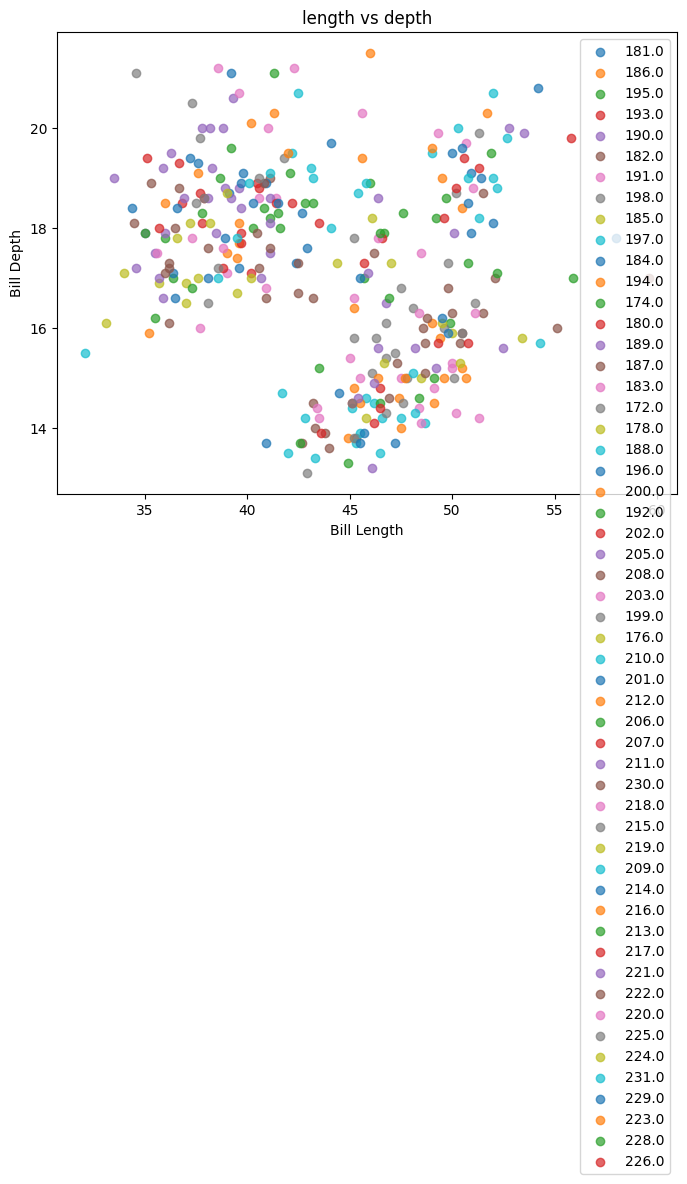

In [5]:
# Scatter plot: pick two interesting features, color by class
# --- SCATTER PLOT (color by class) ---
plt.figure(figsize=(8, 6))
for className in y.unique():
    mask = y == className
    plt.scatter(X.loc[mask, 'bill_length_mm'], X.loc[mask, 'bill_depth_mm'],
                label=className, alpha=0.7)
plt.xlabel('Bill Length')
plt.ylabel('Bill Depth')
plt.title('length vs depth')
plt.legend()
plt.show()

## Step 6: Train/Test Split

In [6]:
# Split 80% train, 20% test
# --- SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


## Step 7: Build and Train the Decision Tree

Use `DecisionTreeClassifier(max_depth=3, random_state=42)` to start. We'll experiment with depth later.

In [7]:
# Create a DecisionTreeClassifier and fit it

# --- BUILD + TRAIN ---
treeModel = DecisionTreeClassifier(max_depth=3, random_state=42)
treeModel.fit(X_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## Step 8: Evaluate

Print the accuracy and the full classification report. The report shows precision, recall, and f1-score for each class.

In [8]:
# Make predictions and print accuracy + classification report
# --- EVALUATE ---
predictions = treeModel.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2%}')
print(classification_report(y_test, predictions))



Accuracy: 29.85%
              precision    recall  f1-score   support

       178.0       0.00      0.00      0.00         1
       180.0       0.00      0.00      0.00         1
       181.0       0.00      0.00      0.00         3
       182.0       0.00      0.00      0.00         1
       185.0       0.12      1.00      0.22         1
       186.0       0.00      0.00      0.00         1
       187.0       0.57      1.00      0.73         4
       188.0       0.00      0.00      0.00         2
       189.0       0.00      0.00      0.00         1
       190.0       1.00      1.00      1.00         4
       191.0       1.00      1.00      1.00         1
       192.0       0.00      0.00      0.00         3
       193.0       0.57      1.00      0.73         4
       195.0       1.00      1.00      1.00         5
       196.0       0.00      0.00      0.00         3
       197.0       0.00      0.00      0.00         0
       198.0       0.00      0.00      0.00         3
       199

C:\Users\mc_edusute26\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mc_edusute26\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mc_edusute26\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

## Step 9: Confusion Matrix

Show the confusion matrix as a heatmap. The diagonal shows correct predictions. Off-diagonal shows mistakes — look at WHERE the model gets confused.

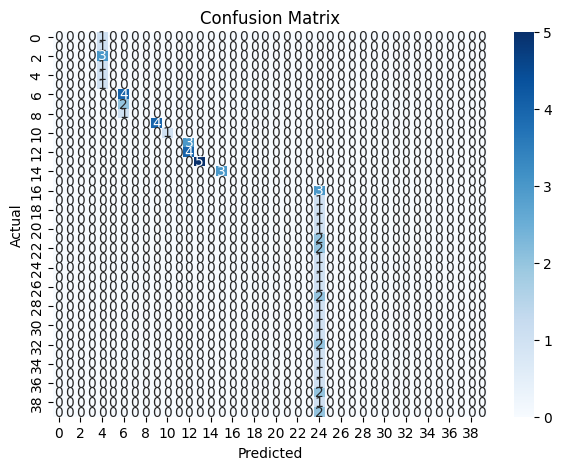

In [9]:
# Confusion matrix heatmap
# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## Step 10: Visualize the Tree

Use `plot_tree` to see the actual decision rules. Read through it — can you follow the yes/no questions from root to leaf?

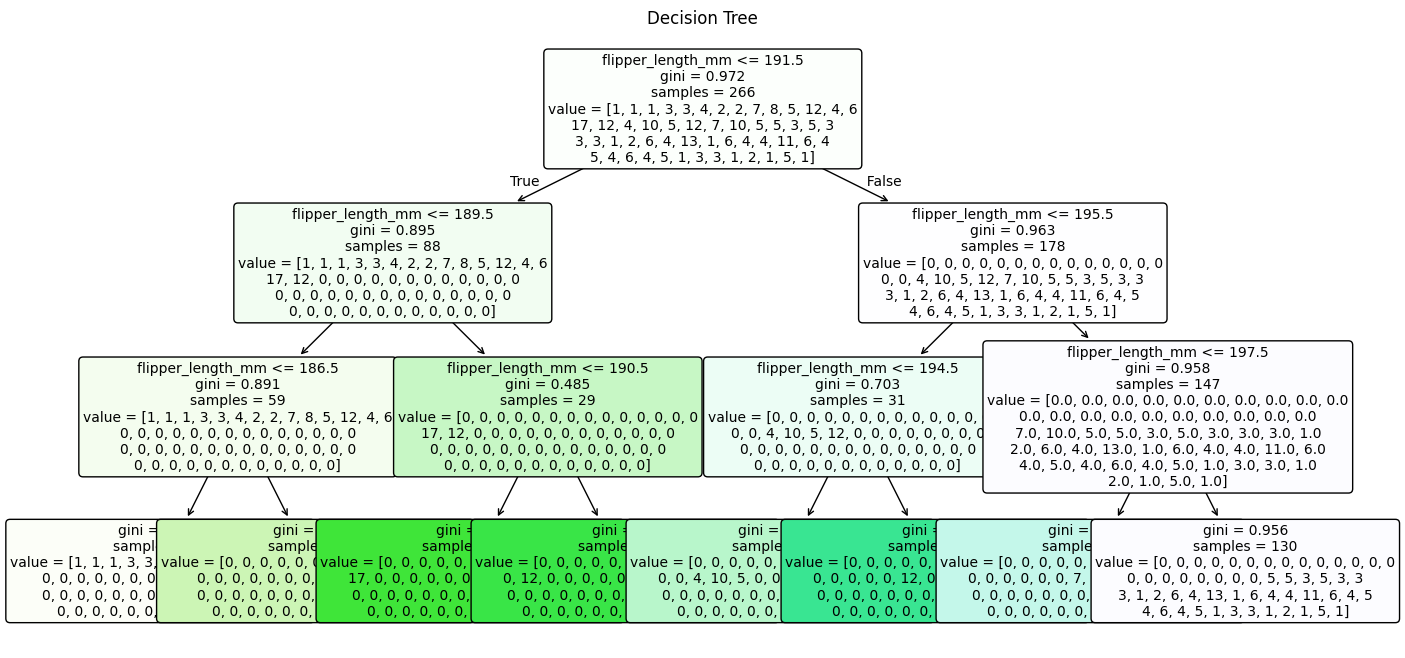

In [10]:
# Draw the decision tree

# --- TREE VISUALIZATION ---
plt.figure(figsize=(16, 8))
plot_tree(treeModel, feature_names=list(X.columns),
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree')
plt.show()


## Step 11: Feature Importance

Show which features the tree uses most. Does this match what you expected from your scatter plot?

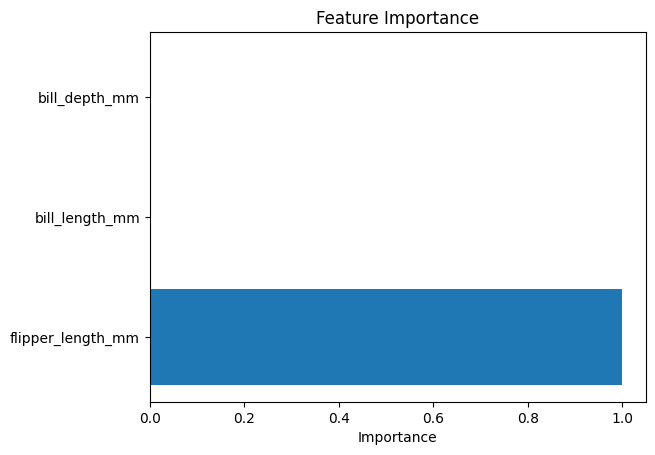

In [11]:
# Feature importance bar chart

# --- FEATURE IMPORTANCE ---
importanceDf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': treeModel.feature_importances_
}).sort_values('Importance', ascending=False)
plt.barh(importanceDf['Feature'], importanceDf['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()


## Step 12: Experiment with max_depth

Try different values of `max_depth` (2, 3, 5, 10, and None for unlimited). Print the accuracy for each. What happens when the tree gets too deep? What happens when it's too shallow?

In [13]:
# Try different max_depth values and compare accuracy

# --- EXPERIMENT WITH DEPTH ---
for depth in [2, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f'max_depth={depth}: accuracy={acc:.2%}')


max_depth=2: accuracy=20.90%
max_depth=3: accuracy=29.85%
max_depth=5: accuracy=53.73%
max_depth=10: accuracy=91.04%
max_depth=None: accuracy=95.52%


## Reflection (answer in this cell)

1. What dataset did you choose and why? Penguins, I wanted to do something that didnt have a lot of features
2. What was your accuracy? Is that good or bad for your dataset? about 30 percent so pretty bad
3. Look at your confusion matrix — where does the model make the most mistakes? Why do you think that is? at 24, im not sure why
4. Which feature was the most important? Does that make real-world sense? the max depth of 10/none
5. What happened when you changed max_depth? Was there a "sweet spot"? unlimited seemed to have the highest
6. How does building a classification model compare to the regression model you built before? What's similar? What's different? this one instead of using traits to compare itself it uses comparisons